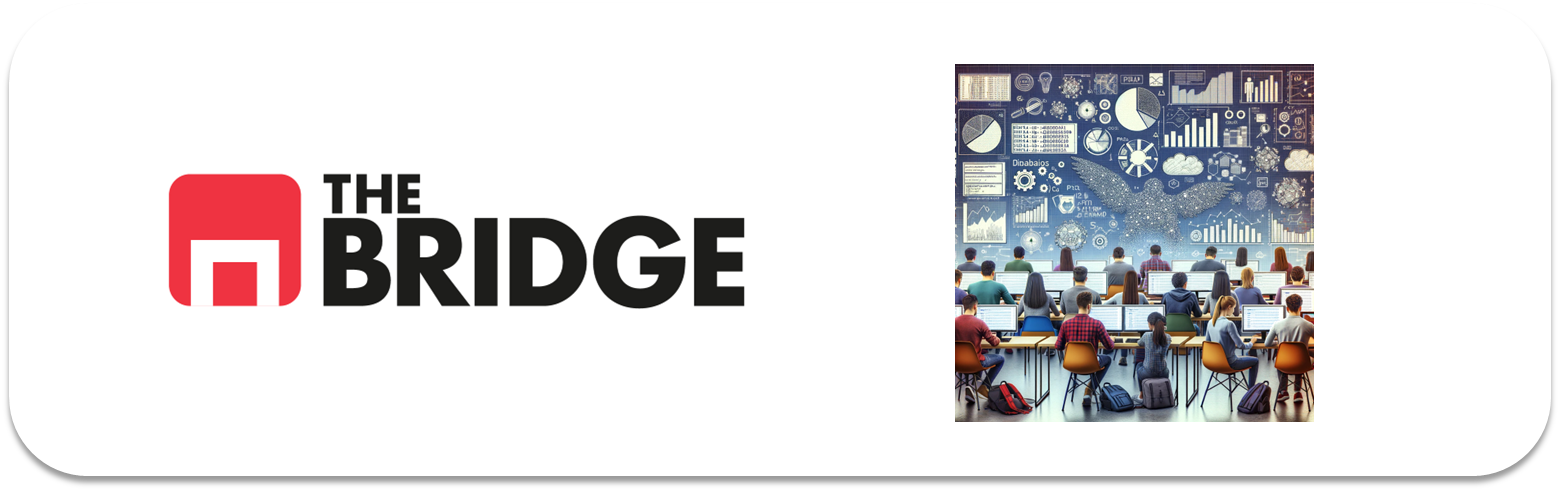

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scipy.stats as stats

1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.


In [9]:
df=pd.read_csv("./data/hard_to_find/obligatoria_hard.csv", sep="|")
display(df)
df.describe()
df.info()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48,22.0


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.


((array([-2.99573567e+00, -2.71411028e+00, -2.55577619e+00, -2.44351800e+00,
         -2.35556494e+00, -2.28276382e+00, -2.22036495e+00, -2.16557440e+00,
         -2.11660431e+00, -2.07223893e+00, -2.03161265e+00, -1.99408648e+00,
         -1.95917475e+00, -1.92649942e+00, -1.89576017e+00, -1.86671438e+00,
         -1.83916307e+00, -1.81294098e+00, -1.78790928e+00, -1.76395019e+00,
         -1.74096288e+00, -1.71886034e+00, -1.69756695e+00, -1.67701655e+00,
         -1.65715093e+00, -1.63791855e+00, -1.61927361e+00, -1.60117517e+00,
         -1.58358651e+00, -1.56647453e+00, -1.54980933e+00, -1.53356377e+00,
         -1.51771316e+00, -1.50223493e+00, -1.48710847e+00, -1.47231481e+00,
         -1.45783653e+00, -1.44365756e+00, -1.42976302e+00, -1.41613915e+00,
         -1.40277318e+00, -1.38965322e+00, -1.37676820e+00, -1.36410778e+00,
         -1.35166231e+00, -1.33942275e+00, -1.32738062e+00, -1.31552796e+00,
         -1.30385728e+00, -1.29236155e+00, -1.28103411e+00, -1.26986869e+00,

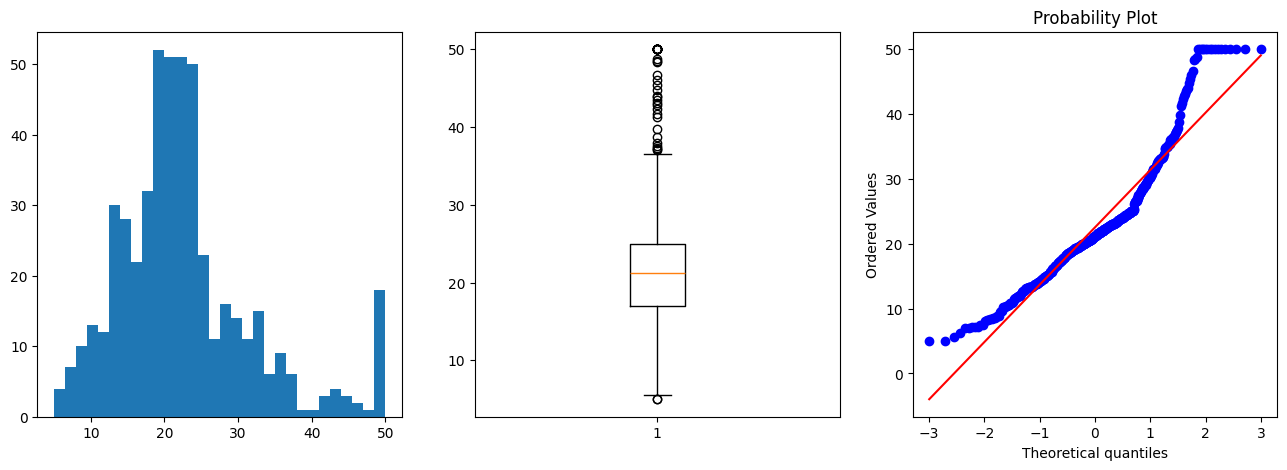

In [13]:
#Variable Target MEDV
fig, axes=plt.subplots(1,3,figsize=(16,5))
axes[0].hist(df.MEDV, bins=30)
axes[1].boxplot(df.MEDV)
stats.probplot(df.MEDV,dist="norm",plot=axes[2])


3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.


In [14]:
train_set, test_set=train_test_split(df, test_size=0.2, random_state=42)
print(f"total filas: {len(df)}")
print(f"total Train filas: {len(train_set)}")
print(f"total Test filas: {len(test_set)}")

total filas: 506
total Train filas: 404
total Test filas: 102



4. Construye las parejas X,y de train y test


In [15]:
#X feautres, y target
y_train=train_set["MEDV"]
y_test=test_set["MEDV"]

X_train=train_set.drop(columns=["MEDV"])
X_test=test_set.drop(columns=["MEDV"])

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (404, 12)
X_test:  (102, 12)
y_train: (404,)
y_test:  (102,)


5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.


<Axes: >

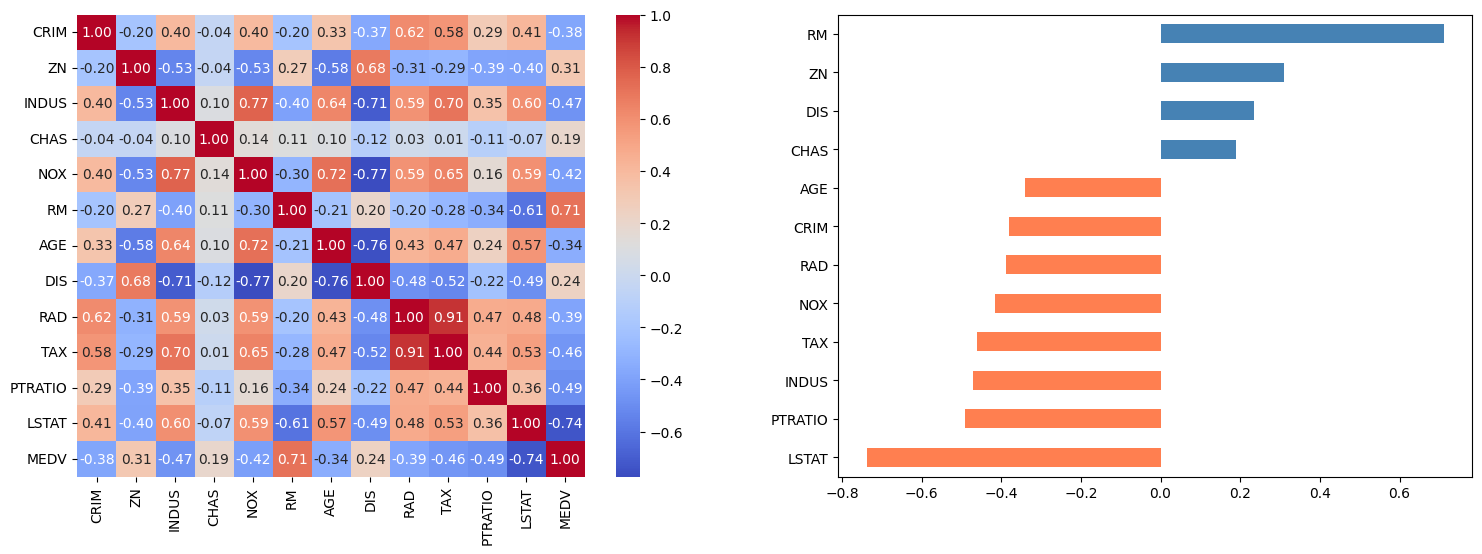

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#Heat map
corr_matrix=train_set.corr()

sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", ax=axes[0])

#correlación con MEDV
corr_con_target=corr_matrix["MEDV"].drop("MEDV").sort_values()
corr_con_target.plot(kind='barh', 
                      color=['coral' if x < 0 else 'steelblue' for x in corr_con_target],
                      ax=axes[1])


In [21]:
# Features seleccionadas
selected_features = ['LSTAT', 'RM', 'PTRATIO', 'NOX', 'INDUS', 'TAX']

# Aplicar selección a X_train y X_test
X_train = X_train[selected_features]
X_test = X_test[selected_features]

# Comprobación
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print("\nFeatures seleccionadas:")
print(X_train.columns.tolist())

X_train: (404, 6)
X_test:  (102, 6)

Features seleccionadas:
['LSTAT', 'RM', 'PTRATIO', 'NOX', 'INDUS', 'TAX']


6. Trata las variables para que funcionen lo mejor posible en el modelo.

In [22]:
from sklearn.preprocessing import StandardScaler

# Crear el scaler
scaler = StandardScaler()

# Fit SOLO en train, transform en ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para visualizar mejor
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

# Comprobación: la media debe ser ~0 y std ~1
print("Media por feature (train):")
print(X_train_scaled.mean().round(2))
print("\nDesviación estándar por feature (train):")
print(X_train_scaled.std().round(2))

Media por feature (train):
LSTAT     -0.0
RM        -0.0
PTRATIO    0.0
NOX       -0.0
INDUS     -0.0
TAX       -0.0
dtype: float64

Desviación estándar por feature (train):
LSTAT      1.0
RM         1.0
PTRATIO    1.0
NOX        1.0
INDUS      1.0
TAX        1.0
dtype: float64


7. Construye un modelo de regresión lineal.


In [24]:
from sklearn.linear_model import LinearRegression

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Ver los pesos del modelo
print(f"Intercepto (β0): {model.intercept_:.4f}")
print("\nPesos de cada feature:")
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Peso': model.coef_
}).sort_values('Peso', ascending=False)

print(coef_df.to_string(index=False))

Intercepto (β0): 22.7965

Pesos de cada feature:
Feature      Peso
     RM  3.641049
  INDUS  0.839537
    NOX -0.343406
    TAX -0.755848
PTRATIO -1.836370
  LSTAT -3.873840



8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los 

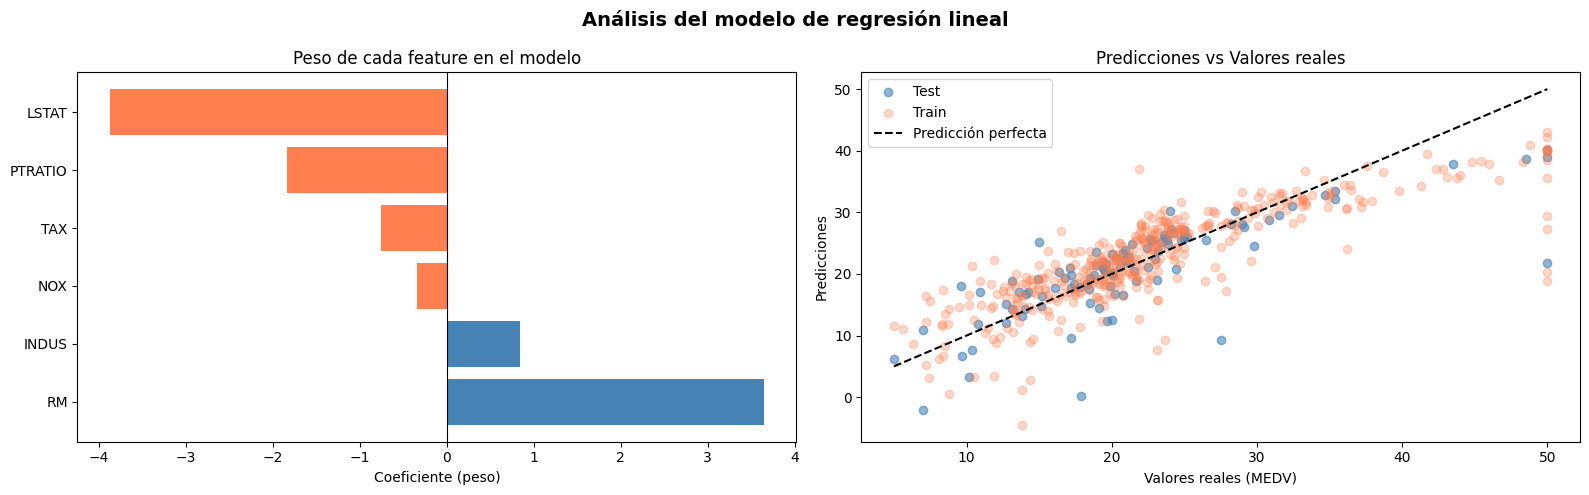

MÉTRICAS EN TRAIN
R²:   0.6907
RMSE: 5.1836
MAE:  3.6345
MÉTRICAS EN TEST
R²:   0.6210
RMSE: 5.2723
MAE:  3.3543


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Análisis del modelo de regresión lineal", fontsize=14, fontweight='bold')

# --- Gráfico 1: Importancia de features ---
colors = ['steelblue' if x > 0 else 'coral' for x in coef_df['Peso']]
axes[0].barh(coef_df['Feature'], coef_df['Peso'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title("Peso de cada feature en el modelo")
axes[0].set_xlabel("Coeficiente (peso)")

# --- Gráfico 2: Predicciones vs Valores reales ---
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

axes[1].scatter(y_test, y_pred_test, color='steelblue', alpha=0.6, label='Test')
axes[1].scatter(y_train, y_pred_train, color='coral', alpha=0.3, label='Train')
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'k--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_xlabel("Valores reales (MEDV)")
axes[1].set_ylabel("Predicciones")
axes[1].set_title("Predicciones vs Valores reales")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Métricas de evaluación ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


print("MÉTRICAS EN TRAIN")
print(f"R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.4f}")


print("MÉTRICAS EN TEST")
print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")

9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.


In [27]:
from sklearn.linear_model import Ridge, Lasso

# Tres valores de alpha a explorar
alphas = [0.1, 1.0, 10.0]

results = []

for alpha in alphas:
    # --- Ridge ---
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    
    # --- Lasso ---
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    y_pred_lasso = lasso.predict(X_test_scaled)
    
    results.append({
        'Modelo': f'Ridge α={alpha}',
        'R²': r2_score(y_test, y_pred_ridge),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        'MAE': mean_absolute_error(y_test, y_pred_ridge)
    })
    results.append({
        'Modelo': f'Lasso α={alpha}',
        'R²': r2_score(y_test, y_pred_lasso),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        'MAE': mean_absolute_error(y_test, y_pred_lasso)
    })

# Añadir regresión lineal base para comparar
results.append({
    'Modelo': 'Regresión Lineal (base)',
    'R²': r2_score(y_test, y_pred_test),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    'MAE': mean_absolute_error(y_test, y_pred_test)
})

# Mostrar tabla comparativa
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(results_df.to_string(index=False))

                 Modelo        R²     RMSE      MAE
            Lasso α=0.1  0.627721 5.224997 3.306301
            Lasso α=1.0  0.627398 5.227263 3.460823
           Ridge α=10.0  0.624873 5.244951 3.335517
            Ridge α=1.0  0.621388 5.269255 3.352291
            Ridge α=0.1  0.620999 5.271964 3.354131
Regresión Lineal (base)  0.620955 5.272269 3.354338
           Lasso α=10.0 -0.023341 8.662877 6.255844



10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?

Analicé la variable MEDV y detecté sesgo positivo y valores atípicos; una transformación logarítmica probablemente habría mejorado la predicción de precios altos. Seleccioné las 6 variables más correlacionadas con el precio, destacando LSTAT y RM, cuya relevancia también confirmó el modelo. La regresión lineal obtuvo un R² de 0,62 en test, mostrando buena generalización pero capacidad explicativa limitada. El modelo predice adecuadamente precios medios, aunque subestima los más altos debido a los outliers. Ridge y Lasso apenas mejoraron los resultados; Lasso con α=10 provocó underfitting severo. Como modelo final elegiría Lasso α=0,1 por su interpretabilidad, aunque en futuros trabajos exploraría log(MEDV) y modelos no lineales como Random Forest.